In [1]:
import os
from pathlib import Path

print("Current folder:")
print(os.getcwd())

print("\nFiles in this folder:")
for f in Path(".").glob("*"):
    print(f.name)

Current folder:
/home/viswaguru/qe_readiness_test/01_scf

Files in this folder:
.ipynb_checkpoints
si_scf_ecutwfc-28.in
si_scf_ecutwfc-16.in
si_scf_ecutwfc-12.out
si_scf_ecutwfc-16.out
si_scf_ecutoff.pwtk
silicon.scf.out
silicon.scf.in
si_scf_ecutwfc-12.in
si_scf_ecutwfc-20.out
tmp
plot_ecutwfc_convergence.ipynb.ipynb
si_scf_ecutwfc-28.out
si_scf_ecutwfc-32.in
si_scf_ecutwfc-20.in
si_scf_ecutwfc-24.in
etot_vs_ecutwfc.dat
si_scf_ecutwfc-24.out
si_scf_ecutwfc-32.out


In [2]:
import pandas as pd
from pathlib import Path

datafile = Path("etot_vs_ecutwfc.dat")

if not datafile.exists():
    datafile = Path("etot-vs-ecutwfc.dat")

df = pd.read_csv(
    datafile,
    sep=r"\s+",
    header=None,
    names=["ecutwfc_Ry", "Etot_Ry"]
)

df

,ecutwfc_Ry,Etot_Ry
0,12,-15.805991
1,16,-15.837356
2,20,-15.845719
3,24,-15.849071
4,28,-15.850088
5,32,-15.850649


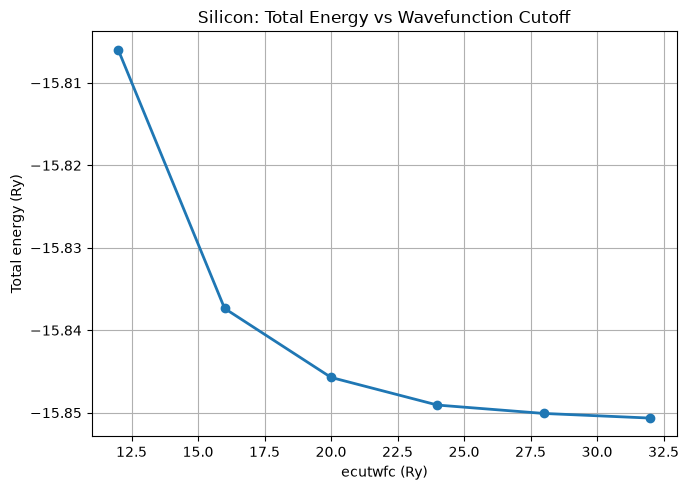

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    df["ecutwfc_Ry"],
    df["Etot_Ry"],
    marker="o",
    linewidth=2
)

plt.xlabel("ecutwfc (Ry)")
plt.ylabel("Total energy (Ry)")
plt.title("Silicon: Total Energy vs Wavefunction Cutoff")
plt.grid(True)

plt.tight_layout()
plt.savefig("etot_vs_ecutwfc_jupyter.png", dpi=300)
plt.show()

In [4]:
nat = 2
Ry_to_meV = 13605.693

Eref = df.loc[df["ecutwfc_Ry"].idxmax(), "Etot_Ry"]

df["DeltaE_meV_per_atom"] = (df["Etot_Ry"] - Eref) * Ry_to_meV / nat

df

,ecutwfc_Ry,Etot_Ry,DeltaE_meV_per_atom
0,12,-15.805991,303.804716
1,16,-15.837356,90.430375
2,20,-15.845719,33.543884
3,24,-15.849071,10.739042
4,28,-15.850088,3.819322
5,32,-15.850649,0.000000


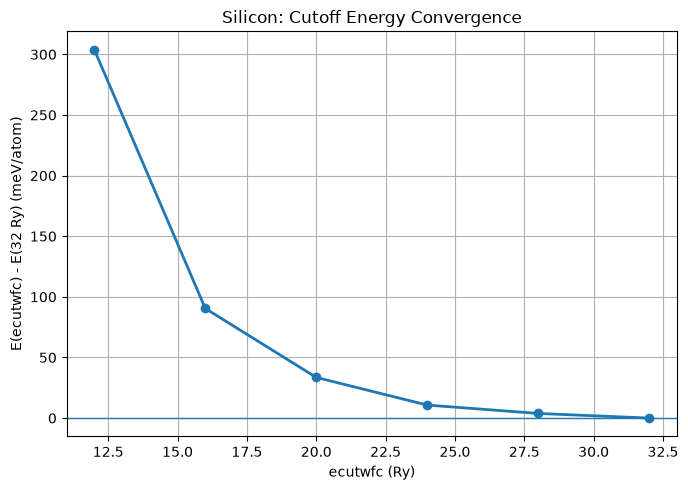

In [5]:
plt.figure(figsize=(7, 5))

plt.plot(
    df["ecutwfc_Ry"],
    df["DeltaE_meV_per_atom"],
    marker="o",
    linewidth=2
)

plt.axhline(0, linewidth=1)

plt.xlabel("ecutwfc (Ry)")
plt.ylabel("E(ecutwfc) - E(32 Ry) (meV/atom)")
plt.title("Silicon: Cutoff Energy Convergence")
plt.grid(True)

plt.tight_layout()
plt.savefig("deltaE_vs_ecutwfc_jupyter.png", dpi=300)
plt.show()

In [6]:
df["abs_DeltaE_meV_per_atom"] = df["DeltaE_meV_per_atom"].abs()

df[["ecutwfc_Ry", "Etot_Ry", "DeltaE_meV_per_atom", "abs_DeltaE_meV_per_atom"]]


,ecutwfc_Ry,Etot_Ry,DeltaE_meV_per_atom,abs_DeltaE_meV_per_atom
0,12,-15.805991,303.804716,303.804716
1,16,-15.837356,90.430375,90.430375
2,20,-15.845719,33.543884,33.543884
3,24,-15.849071,10.739042,10.739042
4,28,-15.850088,3.819322,3.819322
5,32,-15.850649,0.000000,0.000000


In [7]:
df.to_csv("ecutwfc_convergence_processed.csv", index=False)